In [1]:
!pip install gymnasium[toy-text]

In [2]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque


# Environment

In [3]:
#Environment creation and sampling a random action and applying it
env = gym.make("Taxi-v3", render_mode="human")
state, _ = env.reset()

for _ in range(10):
    action = env.action_space.sample()
    env.step(action)

env.close()


# Q Learning

In [4]:
env = gym.make("Taxi-v3")

state_space = env.observation_space.n   # Total number of states in the environment
action_space = env.action_space.n       # Total number of actions available to the agent
Q = np.zeros((state_space, action_space)) # Initialize Q-table with zeros

alpha = 0.1                    #learning rate
gamma = 0.9                    #discount factor
epsilon = 1.0                  #exploration probability
epsilon_min = 0.01             #min exploration
epsilon_decay = 0.999          #rate of exploration decay

episodes = 10000
max_steps = 100

ql_rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    for _ in range(max_steps):
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    ql_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

env.close()


## Plots

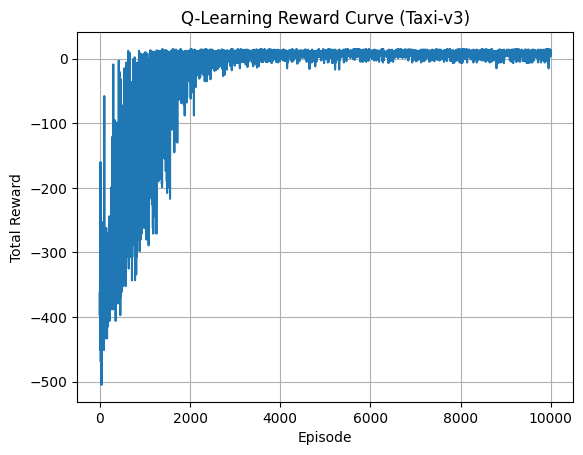

In [5]:
plt.figure()
plt.plot(ql_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning Reward Curve (Taxi-v3)")
plt.grid()
plt.show()


# DQN

In [6]:
def one_hot(state):
    vec = np.zeros(500, dtype=np.float32)
    vec[state] = 1.0
    return vec

In [7]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s2, d):
        self.buffer.append((s, a, r, s2, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            torch.tensor(np.array(states), dtype=torch.float32),
            torch.tensor(actions, dtype=torch.int64),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(np.array(next_states), dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)


In [8]:
class DQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(500, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, 6)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)


In [9]:
env = gym.make("Taxi-v3")

# Initialize policy network and target network to stabilize Q-learning updates
policy_net = DQN()
target_net = DQN()
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

memory = ReplayBuffer()

gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
batch_size = 64
target_update = 10
episodes = 2000
max_steps = 100

dqn_rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    state = one_hot(state)
    total_reward = 0

    for _ in range(max_steps):
        # Selecting action using epsilon-greedy policy (exploration vs exploitation)

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = torch.argmax(
                    policy_net(torch.tensor(state).unsqueeze(0))
                ).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = one_hot(next_state)

        memory.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        # Updating policy network using experience replay and Bellman target

        if len(memory) >= batch_size:
            states, actions, rewards, next_states, dones = memory.sample(batch_size)

            q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
            next_q = target_net(next_states).max(1)[0]
            targets = rewards + gamma * next_q * (1 - dones)

            loss = loss_fn(q_values, targets.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    dqn_rewards.append(total_reward)

    # Updating target network to stabilize training
    if episode % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % 100 == 0:
        print(f"DQN Episode {episode}, Reward {total_reward}")

env.close()


DQN Episode 0, Reward -379
DQN Episode 100, Reward -343
DQN Episode 200, Reward -208
DQN Episode 300, Reward 1
DQN Episode 400, Reward -2
DQN Episode 500, Reward -4
DQN Episode 600, Reward -7
DQN Episode 700, Reward 7
DQN Episode 800, Reward -2
DQN Episode 900, Reward 11
DQN Episode 1000, Reward 4
DQN Episode 1100, Reward -6
DQN Episode 1200, Reward 14
DQN Episode 1300, Reward 13
DQN Episode 1400, Reward -3
DQN Episode 1500, Reward 6
DQN Episode 1600, Reward 6
DQN Episode 1700, Reward 13
DQN Episode 1800, Reward 4
DQN Episode 1900, Reward 5


## Plots

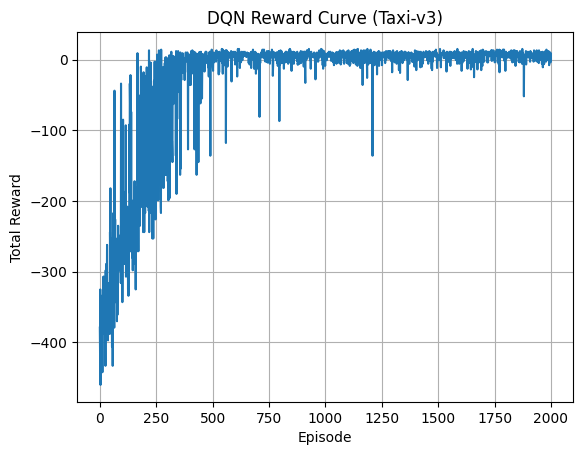

In [10]:
plt.figure()
plt.plot(dqn_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Reward Curve (Taxi-v3)")
plt.grid()
plt.show()


## Smoothed Curve and Comparison

In [11]:
def moving_average(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode="valid")


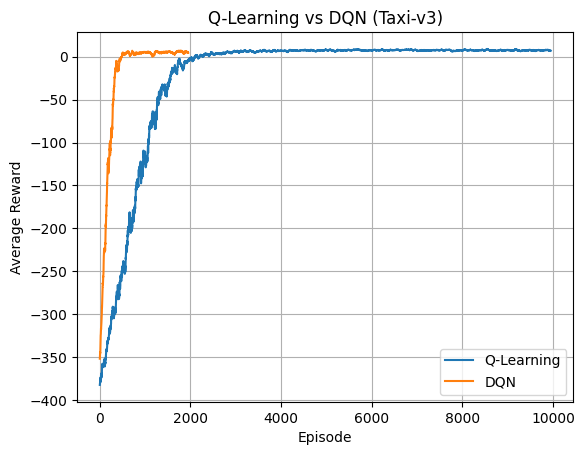

In [12]:
plt.figure()
plt.plot(moving_average(ql_rewards), label="Q-Learning")
plt.plot(moving_average(dqn_rewards), label="DQN")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning vs DQN (Taxi-v3)")
plt.legend()
plt.grid()
plt.show()


#### cut to first 2000 episodes

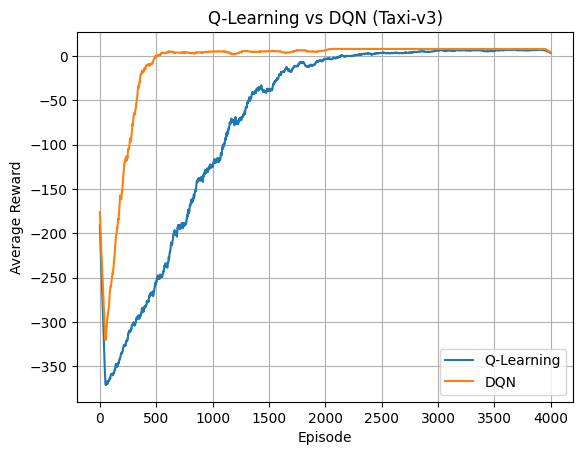

In [14]:
import numpy as np

def moving_average_fixed(x, window=100, target_len=4000):
    x = np.asarray(x)

    # Trim or pad input first
    if len(x) >= target_len:
        x = x[:target_len]
    else:
        x = np.pad(x, (0, target_len - len(x)), mode="edge")

    # Moving average with same length
    kernel = np.ones(window) / window
    ma = np.convolve(x, kernel, mode="same")

    return ma


ql_ma = moving_average_fixed(ql_rewards, window=100, target_len=4000)
dqn_ma = moving_average_fixed(dqn_rewards, window=100, target_len=4000)

plt.figure()
plt.plot(ql_ma, label="Q-Learning")
plt.plot(dqn_ma, label="DQN")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning vs DQN (Taxi-v3)")
plt.legend()
plt.grid()
plt.show()
